# Neuron Classification Demo Notebook
This demo notebook illustrates how to classify neurons as component, pattern or unclassified on the basis of their responses to drifting grating and plaid stimuli. The data is from the three example neurons in Figure 2, and the notebook requires NumPy, SciPy, and Matplotlib. The expected run time is less than one minute.

### 1. Import dependencies and load the data
This cell loads example tuning curves (with error bars) for three neurons. Note that when running the main analysis pipeline, this information is saved in outputs/pattern.pkl. 


In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# define the data
data = {'directions_deg': [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330],
 'patcomp_split': 1.28,
 'cells': [{'label': 'Pattern',
            'grating_tuning': [14.832535885167463,
                               11.784511784511785,
                               4.70219435736677,
                               0.26737967914438504,
                               0.8741258741258742,
                               1.859504132231405,
                               2.4064171122994655,
                               2.878787878787879,
                               1.2987012987012987,
                               0.8116883116883118,
                               2.3636363636363638,
                               9.090909090909092],
            'plaid_tuning': [34.37499999999999,
                             27.738927738927732,
                             23.07692307692307,
                             6.9930069930069925,
                             2.972027972027972,
                             1.3986013986013985,
                             1.6835016835016836,
                             1.1363636363636362,
                             1.859504132231405,
                             4.692082111436951,
                             17.454545454545457,
                             30.68181818181818],
            'grating_sem': [1.732500875789508,
                            1.144666874257832,
                            0.9158603374929492,
                            0.267379679144385,
                            0.3582849918167692,
                            0.7114504600468683,
                            0.6882105709215909,
                            0.5103346006710026,
                            0.459160247523732,
                            0.3350320277959363,
                            0.5938156952201643,
                            1.48490592676492],
            'plaid_sem': [2.225849948042847,
                          1.4822354360415784,
                          2.031585880606147,
                          1.0157929403030737,
                          0.7950221678952498,
                          0.4195804195804196,
                          0.5504898033367593,
                          0.3535062595671904,
                          0.7114504600468682,
                          0.8022194111571588,
                          1.9757482803276412,
                          3.134530024814605]},
           {'label': 'Component',
            'grating_tuning': [24.880382775119617,
                               19.528619528619526,
                               5.642633228840126,
                               2.941176470588235,
                               0.6993006993006993,
                               2.479338842975207,
                               1.6042780748663101,
                               1.0606060606060606,
                               0.487012987012987,
                               1.6233766233766236,
                               4.909090909090909,
                               12.450592885375496],
            'plaid_tuning': [17.045454545454543,
                             31.002331002331005,
                             34.61538461538461,
                             18.006993006993007,
                             2.097902097902098,
                             3.1468531468531467,
                             2.861952861952862,
                             1.1363636363636362,
                             3.3057851239669422,
                             14.809384164222871,
                             31.090909090909093,
                             33.522727272727266],
            'grating_sem': [2.2891068731112156,
                            2.2864750580164115,
                            1.308700331052616,
                            0.6684491978609626,
                            0.4137118729440291,
                            0.7157234742020153,
                            0.5430506954970561,
                            0.35700146929689675,
                            0.2705627705627705,
                            0.4799471390927154,
                            0.8672174558335868,
                            2.0847013588732],
            'plaid_sem': [2.010121681943577,
                          2.2887534262391305,
                          4.026903510178452,
                          2.1759941094407846,
                          0.5766581294570154,
                          0.9689794727658055,
                          0.6925533259321904,
                          0.5399897310357857,
                          0.8554531727384557,
                          1.6858982230856083,
                          3.123711855721612,
                          3.0073135690152966]},
           {'label': 'Unclassified',
            'grating_tuning': [23.684210526315788,
                               17.34006734006734,
                               9.09090909090909,
                               3.20855614973262,
                               2.797202797202797,
                               2.892561983471074,
                               2.6737967914438507,
                               1.8181818181818181,
                               2.11038961038961,
                               9.09090909090909,
                               17.272727272727273,
                               26.679841897233203],
            'plaid_tuning': [14.77272727272727,
                             20.629370629370626,
                             16.258741258741257,
                             4.195804195804196,
                             1.048951048951049,
                             1.3986013986013985,
                             2.6936026936026933,
                             4.119318181818182,
                             8.264462809917358,
                             28.29912023460411,
                             41.454545454545446,
                             33.71212121212121],
            'grating_sem': [2.268175861774783,
                            1.6639632846144339,
                            1.5951418325990827,
                            1.2788186142853601,
                            0.7165699836335383,
                            0.8742565876238907,
                            0.8766629043184492,
                            0.5598925109558542,
                            0.7569312863765254,
                            1.685904970497536,
                            1.7007533576245188,
                            2.463338938820334],
            'plaid_sem': [1.6199691931073574,
                          1.5106621674610397,
                          1.9880935630530767,
                          0.9063973004766237,
                          0.3830227674861301,
                          0.48951048951048953,
                          0.6536870999287211,
                          0.8255052408228348,
                          1.453990806919415,
                          1.8701003391699895,
                          2.866641040310853,
                          2.679599061031256]}]}

# load the data
cells = data["cells"]
grating, plaid, grating_sem, plaid_sem = (
    np.array([cell[key] for cell in cells])
    for key in ("grating_tuning", "plaid_tuning", "grating_sem", "plaid_sem")
)
labels = [cell["label"] for cell in cells]
colors = ["tab:orange", "tab:blue", "0.6"]
threshold = data["patcomp_split"]

### 2. Plot tuning curves for each neuron to gratings and plaids
This cell plots the polar tuning curves for the three example neurons to gratings and plaids. We provide the _plot_single_polar_tuning function here for ease of use, copied from plotting/plot_utils.py in the motion-processing-circuits repository. 

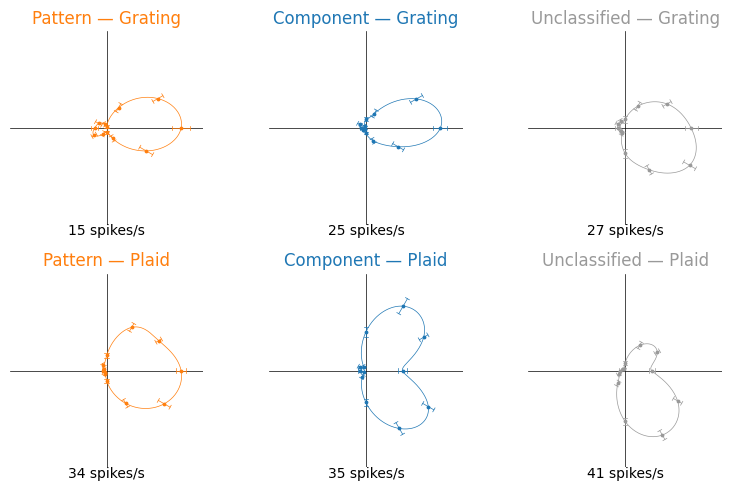

In [25]:
# Copied from plotting/plot_utils.py.
def _plot_single_polar_tuning(ax, tuning, tuning_sem, baseline_rate_hz, scale, color="k", ls="-", add_error=True, add_baseline=False, size_mult=1.0):
    tuning = np.asarray(tuning, float)
    tuning_sem = np.asarray(tuning_sem, float)
    n_dirs = tuning.size

    dirs = np.arange(n_dirs) * (360.0 / float(n_dirs))
    angles = np.deg2rad(dirs)
    r = np.asarray(tuning, float) / scale 
    sem_r = np.asarray(tuning_sem, float) / scale
    br = float(baseline_rate_hz) / float(scale)
    xs = r * np.cos(angles)
    ys = r * np.sin(angles)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.plot([-1.3, 1.3], [0.0, 0.0], color="k", lw=0.5, zorder=0)
    ax.plot([0.0, 0.0], [-1.3, 1.3], color="k", lw=0.5, zorder=0)

    ax.scatter(xs, ys, color=color, marker=".", s=12*size_mult, zorder=3)

    if add_error:
        cap_len = 0.03
        for a, ri, sei in zip(angles, r, sem_r):
            ux, uy = np.cos(a), np.sin(a)
            tx, ty = -uy, ux
            x0, y0 = (ri - sei) * ux, (ri - sei) * uy
            x1, y1 = (ri + sei) * ux, (ri + sei) * uy

            ax.plot([x0, x1], [y0, y1], color=color, lw=0.5, zorder=2)
            ax.plot(
                [x0 - cap_len * tx, x0 + cap_len * tx],
                [y0 - cap_len * ty, y0 + cap_len * ty],
                color=color,
                lw=0.5,
                zorder=2,
            )
            ax.plot(
                [x1 - cap_len * tx, x1 + cap_len * tx],
                [y1 - cap_len * ty, y1 + cap_len * ty],
                color=color,
                lw=0.5,
                zorder=2,
            )

    x = np.arange(n_dirs + 1) * (360.0 / float(n_dirs))
    cs = CubicSpline(
        x,
        np.concatenate((tuning, [tuning[0]]), axis=0),
        bc_type="periodic",
    )
    ang_i = np.linspace(0.0, 360.0, 500)
    tun_i = cs(ang_i)
    r_i = np.asarray(tun_i, float) / scale
    xs_i = r_i * np.cos(np.deg2rad(ang_i))
    ys_i = r_i * np.sin(np.deg2rad(ang_i))
    ax.plot(np.r_[xs_i, xs_i[0]], np.r_[ys_i, ys_i[0]], color=color, lw=0.5, ls=ls, zorder=1)
    if add_baseline:
        ax.add_patch(plt.Circle((0, 0), br, fill=False, ec=color, lw=0.5, ls='--', zorder=1))
        
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for j, (cell, color) in enumerate(zip(cells, colors)):
    for i, (tuning, sem, name) in enumerate(((grating, grating_sem, "Grating"),
                                           (plaid, plaid_sem, "Plaid"))):
        scale = tuning[j].max()
        _plot_single_polar_tuning(axes[i, j], tuning[j], sem[j],
                                 0.0, scale, color=color)
        axes[i, j].set_title(f"{labels[j]} — {name}", color=color)
        axes[i, j].text(0.5, -0.05, f"{scale:.0f} spikes/s",
                        transform=axes[i, j].transAxes, ha="center")
plt.tight_layout()
plt.show()

### 3. Compute partial correlations
This cell computes the partial correlation and z-transformed partial correlations between the measured plaid tuning and predicted plaid tuning under the grating and plaid model, then plots the results. This code is adapted from analysis/pattern_metrics.py and plotting/plot_class.py.

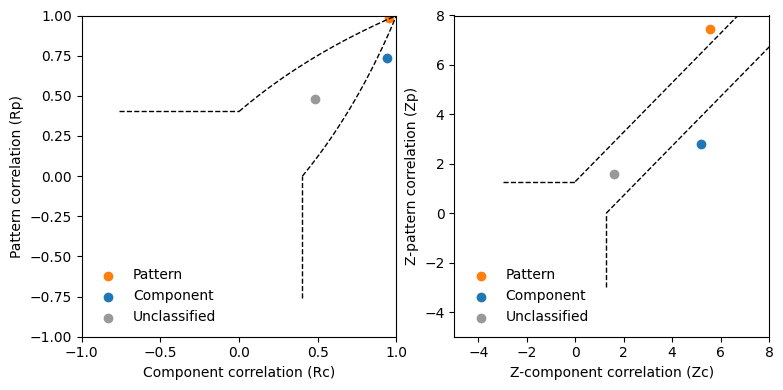

In [26]:
# From analysis/pattern_metrics.py, using the saved direction means.
rp, rc = np.zeros(3), np.zeros(3)
for i in range(3):
    measured = plaid[i]
    patt_pred = grating[i]
    comp_pred = np.roll(grating[i], -2) + np.roll(grating[i], 2)  # ±60°

    r_p = np.clip(np.corrcoef(measured, patt_pred)[0, 1], -0.9999, 0.9999)
    r_c = np.clip(np.corrcoef(measured, comp_pred)[0, 1], -0.9999, 0.9999)
    r_pc = np.clip(np.corrcoef(comp_pred, patt_pred)[0, 1], -0.9999, 0.9999)
    rp[i] = (r_p - r_c * r_pc) / np.sqrt((1 - r_c**2) * (1 - r_pc**2))
    rc[i] = (r_c - r_p * r_pc) / np.sqrt((1 - r_p**2) * (1 - r_pc**2))

# From analysis/pattern_metrics.py, z-transformed. 
df = len(data["directions_deg"]) - 3
zp = 0.5 * np.log((1 + rp) / (1 - rp)) * np.sqrt(df)
zc = 0.5 * np.log((1 + rc) / (1 - rc)) * np.sqrt(df)

# Classification boundaries from plotting/plot_class.py.
def fisher_z_inverse(out):
    coef = np.exp(2 * out)
    return (coef - 1) / (coef + 1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs[0]
for i in range(3):
    ax.scatter(rc[i], rp[i], color=colors[i], label=labels[i])
x = np.linspace(0, 10, 100)
sd = np.sqrt(1 / (12 - 3))
ax.plot(fisher_z_inverse(x * sd), fisher_z_inverse((x + threshold) * sd), "k--", lw=1)
ax.plot(fisher_z_inverse((x + threshold) * sd), fisher_z_inverse(x * sd), "k--", lw=1)
ax.plot(fisher_z_inverse(np.array([threshold, threshold]) * sd),
        fisher_z_inverse(np.array([-3, 0]) * sd), "k--", lw=1)
ax.plot(fisher_z_inverse(np.array([-3, 0]) * sd),
        fisher_z_inverse(np.array([threshold, threshold]) * sd), "k--", lw=1)
ax.set(xlim=(-1, 1), ylim=(-1, 1),
       xlabel="Component correlation (Rc)", ylabel="Pattern correlation (Rp)")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()

ax = axs[1]
for i in range(3):
    ax.scatter(zc[i], zp[i], color=colors[i], label=labels[i])
x = np.linspace(0, 7, 100)
ax.plot(x, x + threshold, "k--", lw=1)
ax.plot(x + threshold, x, "k--", lw=1)
ax.plot([threshold, threshold], [-3, 0], "k--", lw=1)
ax.plot([-3, 0], [threshold, threshold], "k--", lw=1)
ax.set(xlim=(-5, 8), ylim=(-5, 8),
       xlabel="Z-component correlation (Zc)", ylabel="Z-pattern correlation (Zp)")
ax.legend(frameon=False, loc="lower left")
plt.show()

### 4. Compute pattern index and assign neuron labels
This cell computes the pattern index and assigns neuron labels. This code is adapted from analysis/pattern_metrics.py and prints the classification and pattern index metrics as reported in Fig. 2. 

In [27]:
pi = zp - zc
is_pds = (pi >= threshold) & (zp >= threshold)
is_cds = (pi <= -threshold) & (zc >= threshold)
classification = np.where(is_pds, "Pattern", np.where(is_cds, "Component", "Unclassified"))

print(f"{'Cell':<14} {'Rp':>8} {'Rc':>8} {'Zp':>8} {'Zc':>8} {'PI':>8}")
for i in range(3):
    print(f"{classification[i]:<14} {rp[i]:8.4f} {rc[i]:8.4f} "
          f"{zp[i]:8.4f} {zc[i]:8.4f} {pi[i]:8.4f}")

Cell                 Rp       Rc       Zp       Zc       PI
Pattern          0.9862   0.9524   7.4524   5.5721   1.8803
Component        0.7350   0.9389   2.8188   5.1860  -2.3672
Unclassified     0.4805   0.4852   1.5707   1.5895  -0.0187
